<a href="https://www.kaggle.com/code/nonnt66/progetto-tecquant?scriptVersionId=314756147" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## creazione JSON input


In [9]:
## CREAZIONE JSON
import json
import random
from collections import defaultdict

random.seed(42)

N = 60
GROUP_COUNT = 40
TARGET_EDGES = 1000
MIN_DEGREE = 3
# -----------------------------
# Utility
# -----------------------------
def clamp01(x):
    return max(0.0, min(1.0, x))

def r4(x):
    return round(clamp01(x), 4)

def trunc_norm(mean, std, lo=0.0, hi=1.0):
    while True:
        v = random.gauss(mean, std)
        if lo <= v <= hi:
            return v

# -----------------------------
# Group distribution non-uniform
# -----------------------------
groups = [f"G{i:02d}" for i in range(GROUP_COUNT)]
# pesi non uniformi: alcuni gruppi molto grandi
weights = []
for i in range(GROUP_COUNT):
    if i < 8:
        w = random.uniform(2.5, 4.0)   # gruppi grandi
    elif i < 20:
        w = random.uniform(1.2, 2.2)   # medi
    else:
        w = random.uniform(0.5, 1.1)   # piccoli
    weights.append(w)

# normalizza e alloca cardinalità esatta N
w_sum = sum(weights)
raw_sizes = [N * w / w_sum for w in weights]
sizes = [int(x) for x in raw_sizes]
while sum(sizes) < N:
    idx = max(range(GROUP_COUNT), key=lambda i: raw_sizes[i] - sizes[i])
    sizes[idx] += 1

group_of = []
for gi, sz in enumerate(sizes):
    group_of.extend([groups[gi]] * sz)
random.shuffle(group_of)

# -----------------------------
# Generate channels
# -----------------------------
channels = []
for i in range(N):
    g = group_of[i]

    # "legacy factor": alcuni gruppi più legacy
    g_idx = int(g[1:])
    legacy_bias = 0.15 if g_idx < 10 else (0.05 if g_idx < 25 else -0.05)
    edge_bias = 0.12 if g_idx % 5 == 0 else 0.0

    cvss = trunc_norm(0.58 + legacy_bias * 0.2, 0.16)
    # outlier alti occasionali
    if random.random() < 0.04:
        cvss = max(cvss, random.uniform(0.9, 1.0))

    exploit_prob = clamp01(0.15 + 0.75 * cvss + random.gauss(0, 0.09))
    patch_lag = clamp01(0.20 + 0.60 * cvss + legacy_bias + random.gauss(0, 0.12))
    exposure = clamp01(0.25 + 0.55 * cvss + edge_bias + random.gauss(0, 0.14))

    # performance correlate
    latency = clamp01(0.15 + 0.45 * exposure + 0.20 * cvss + random.gauss(0, 0.10))
    jitter = clamp01(0.10 + 0.55 * latency + random.gauss(0, 0.08))
    loss = clamp01(0.08 + 0.45 * latency + 0.25 * jitter + random.gauss(0, 0.08))

    # compliance: molti 0, alcuni 0.2/0.5, pochi 1.0
    p = random.random()
    if p < 0.72:
        compliance = 0.0
    elif p < 0.88:
        compliance = 0.2
    elif p < 0.97:
        compliance = 0.5
    else:
        compliance = 1.0

    channels.append({
        "id": i,
        "cvss": r4(cvss),
        "exploit_prob": r4(exploit_prob),
        "patch_lag": r4(patch_lag),
        "exposure": r4(exposure),
        "latency": r4(latency),
        "jitter": r4(jitter),
        "loss": r4(loss),
        "compliance": r4(compliance),
        "group": g
    })

# -----------------------------
# Build correlations graph
# -----------------------------
group_to_ids = defaultdict(list)
for c in channels:
    group_to_ids[c["group"]].append(c["id"])

edges = set()  # store tuple(i,j) with i<j
degree = [0] * N

def add_edge(i, j, score):
    if i == j:
        return False
    a, b = (i, j) if i < j else (j, i)
    if (a, b) in edges:
        return False
    edges.add((a, b))
    degree[a] += 1
    degree[b] += 1
    return True

# Step 1: guarantee min degree >= MIN_DEGREE
all_ids = list(range(N))
for i in all_ids:
    attempts = 0
    while degree[i] < MIN_DEGREE and attempts < 4000:
        attempts += 1
        same_group = random.random() < 0.55
        gi = channels[i]["group"]
        if same_group and len(group_to_ids[gi]) > 1:
            j = random.choice(group_to_ids[gi])
            if j == i:
                continue
            base = 0.65
            score = r4(random.gauss(base, 0.12))
        else:
            # cross-group
            g2 = random.choice(groups)
            while g2 == gi or len(group_to_ids[g2]) == 0:
                g2 = random.choice(groups)
            j = random.choice(group_to_ids[g2])
            base = 0.25
            score = r4(random.gauss(base, 0.10))
        add_edge(i, j, score)

# Step 2: add random edges up to TARGET_EDGES
while len(edges) < TARGET_EDGES:
    same_group = random.random() < 0.45
    if same_group:
        g = random.choice(groups)
        ids = group_to_ids[g]
        if len(ids) < 2:
            continue
        i, j = random.sample(ids, 2)
        score = r4(random.gauss(0.65, 0.12))
    else:
        g1, g2 = random.sample(groups, 2)
        if not group_to_ids[g1] or not group_to_ids[g2]:
            continue
        i = random.choice(group_to_ids[g1])
        j = random.choice(group_to_ids[g2])
        score = r4(random.gauss(0.25, 0.10))
    add_edge(i, j, score)

# convert to list of objects
correlations = []
for (i, j) in sorted(edges):
    # score ricalcolato coerente con same/diff group
    if channels[i]["group"] == channels[j]["group"]:
        score = r4(random.gauss(0.65, 0.12))
    else:
        score = r4(random.gauss(0.25, 0.10))
    correlations.append({"i": i, "j": j, "score": score})

# -----------------------------
# Final JSON
# -----------------------------
data = {
    "channels": channels,
    "correlations": correlations,
    "constraints": {
        "K": 180,
        "weights": {
            "alpha": 1.0,
            "beta": 0.8,
            "gamma": 0.4,
            "delta": 0.7,
            "A": 6.0,
            "B": 3.0
        },
        "internal_weights": {
            "w_cvss": 0.35,
            "w_expl": 0.25,
            "w_patch": 0.20,
            "w_expo": 0.20,
            "w_lat": 0.5,
            "w_jit": 0.3,
            "w_loss": 0.2
        }
    }
}

# -----------------------------
# Validation
# -----------------------------
assert len(data["channels"]) == N
assert [c["id"] for c in data["channels"]] == list(range(N))
for c in data["channels"]:
    for k in ["cvss","exploit_prob","patch_lag","exposure","latency","jitter","loss","compliance"]:
        assert 0.0 <= c[k] <= 1.0
    assert c["group"] in groups

seen = set()
deg_check = [0]*N
for e in data["correlations"]:
    i, j, s = e["i"], e["j"], e["score"]
    assert 0 <= i < N and 0 <= j < N and i < j
    assert (i, j) not in seen
    seen.add((i, j))
    assert 0.0 <= s <= 1.0
    deg_check[i] += 1
    deg_check[j] += 1

# assert all(d >= MIN_DEGREE for d in deg_check), "Alcuni nodi hanno degree < MIN_DEGREE"
assert 1 <= len(data["correlations"]) <= 25000

with open("cyber_input_large.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False)

print(f"Creato cyber_input_large.json con {len(channels)} channels e {len(correlations)} correlations.")

Creato cyber_input_large.json con 60 channels e 1000 correlations.


## *import*


In [10]:
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from collections import defaultdict
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit import transpile



## *function defines* 

In [11]:
# ==========================================================
# Load JSON
# ==========================================================
def load_problem(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    channels = sorted(data["channels"], key=lambda x: x["id"])
    n = len(channels)

    ids = [c["id"] for c in channels]
    if ids != list(range(n)):
        raise ValueError("IDs non consecutivi 0..N-1")

    constraints = data["constraints"]
    # K = int(constraints["K"])
    K = max(1, min(n, int(round(0.15 * n))))  # n=60 -> K=9
    if K < 0 or K > n:
        raise ValueError(f"constraints.K invalido: K={K}, ma n={n}. Deve valere 0 <= K <= n.")
    w = constraints["weights"]
    iw = constraints.get("internal_weights", {})

    alpha = float(w["alpha"]); beta = float(w["beta"]); gamma = float(w["gamma"]); delta = float(w["delta"])
    A = float(w["A"]); B = float(w["B"])

    w_cvss = float(iw.get("w_cvss", 0.35))
    w_expl = float(iw.get("w_expl", 0.25))
    w_patch = float(iw.get("w_patch", 0.20))
    w_expo = float(iw.get("w_expo", 0.20))
    w_lat = float(iw.get("w_lat", 0.5))
    w_jit = float(iw.get("w_jit", 0.3))
    w_loss = float(iw.get("w_loss", 0.2))

    def arr(key, default=0.0):
        return np.array([float(c.get(key, default)) for c in channels], dtype=float)

    cvss = arr("cvss")
    exploit_prob = arr("exploit_prob")
    patch_lag = arr("patch_lag")
    exposure = arr("exposure")
    latency = arr("latency")
    jitter = arr("jitter")
    loss = arr("loss")
    compliance = arr("compliance")
    groups_labels = [c["group"] for c in channels]

    group_map = defaultdict(list)
    for i, g in enumerate(groups_labels):
        group_map[g].append(i)
    groups = list(group_map.values())

    corr = np.zeros((n, n), dtype=float)
    seen = set()
    for e in data["correlations"]:
        i = int(e["i"]); j = int(e["j"]); s = float(e["score"])
        if not (0 <= i < n and 0 <= j < n and i < j):
            continue
        if (i, j) in seen:
            continue
        seen.add((i, j))
        corr[i, j] = s
        corr[j, i] = s

    return {
        "n": n, "K": K, "groups": groups, "groups_labels": groups_labels,
        "cvss": cvss, "exploit_prob": exploit_prob, "patch_lag": patch_lag, "exposure": exposure,
        "latency": latency, "jitter": jitter, "loss": loss, "compliance": compliance, "corr": corr,
        "alpha": alpha, "beta": beta, "gamma": gamma, "delta": delta, "A": A, "B": B,
        "w_cvss": w_cvss, "w_expl": w_expl, "w_patch": w_patch, "w_expo": w_expo,
        "w_lat": w_lat, "w_jit": w_jit, "w_loss": w_loss
    }

# ==========================================================
# Build QUBO
# ==========================================================
def build_qubo(p):
    n = p["n"]
    K = p["K"]
    groups = p["groups"]

    risk_intrinsic = (
        p["w_cvss"] * p["cvss"] +
        p["w_expl"] * p["exploit_prob"] +
        p["w_patch"] * p["patch_lag"] +
        p["w_expo"] * p["exposure"]
    )
    sla_cost = p["w_lat"] * p["latency"] + p["w_jit"] * p["jitter"] + p["w_loss"] * p["loss"]
    linear_base = p["alpha"] * risk_intrinsic + p["gamma"] * sla_cost + p["delta"] * p["compliance"]

    Q = np.zeros((n, n), dtype=float)
    c = 0.0

    # lineari
    for i in range(n):
        Q[i, i] += linear_base[i]

    # correlazioni
    beta = p["beta"]
    corr = p["corr"]
    for i in range(n):
        for j in range(i + 1, n):
            coeff = beta * corr[i, j]
            if coeff != 0.0:
                Q[i, j] += coeff / 2.0
                Q[j, i] += coeff / 2.0

    # cardinalità
    A = p["A"]; K = p["K"]
    for i in range(n):
        Q[i, i] += A * (1 - 2 * K)
    c += A * (K ** 2)
    for i in range(n):
        for j in range(i + 1, n):
            coeff = 2 * A
            Q[i, j] += coeff / 2.0
            Q[j, i] += coeff / 2.0

    # anti-SPoF group
    B = p["B"]
    for g in groups:
        if len(g) <= 1:
            continue
        for i in g:
            Q[i, i] += B * (1 - 2 * 1)
        c += B
        for a in range(len(g)):
            for b in range(a + 1, len(g)):
                i, j = g[a], g[b]
                coeff = 2 * B
                Q[i, j] += coeff / 2.0
                Q[j, i] += coeff / 2.0

    return Q, c

# ==========================================================
# Helpers
# ==========================================================
def qubo_cost(x, Q, c):
    x = np.asarray(x, dtype=float)
    return float(x @ Q @ x + c)

def qubo_to_sparse_pauli(Qb, cb=0.0, tol=1e-12):
    Qb = np.asarray(Qb, dtype=float)
    n = Qb.shape[0]
    Qs = 0.5 * (Qb + Qb.T)

    const = float(cb)
    h = np.zeros(n, dtype=float)
    Jzz = np.zeros((n, n), dtype=float)

    for i in range(n):
        qii = Qs[i, i]
        const += 0.5 * qii
        h[i] += -0.5 * qii

    for i in range(n):
        for j in range(i + 1, n):
            bij = 2.0 * Qs[i, j]
            const += 0.25 * bij
            h[i] += -0.25 * bij
            h[j] += -0.25 * bij
            Jzz[i, j] += 0.25 * bij

    paulis, coeffs = [], []
    if abs(const) > tol:
        paulis.append("I" * n)
        coeffs.append(const)

    for i in range(n):
        if abs(h[i]) > tol:
            label = ["I"] * n
            label[n - 1 - i] = "Z"
            paulis.append("".join(label))
            coeffs.append(h[i])

    for i in range(n):
        for j in range(i + 1, n):
            if abs(Jzz[i, j]) > tol:
                label = ["I"] * n
                label[n - 1 - i] = "Z"
                label[n - 1 - j] = "Z"
                paulis.append("".join(label))
                coeffs.append(Jzz[i, j])

    if not paulis:
        paulis, coeffs = ["I" * n], [0.0]

    return SparsePauliOp(paulis, coeffs=np.array(coeffs, dtype=float))

def make_blocks(n_vars, block_size=24):
    idx = np.arange(n_vars)
    return [idx[i:i + block_size] for i in range(0, n_vars, block_size)]

def subqubo_with_context(Q, x_fixed, block):
    n = Q.shape[0]
    block = np.asarray(block, dtype=int)
    mask = np.ones(n, dtype=bool)
    mask[block] = False
    rest = np.where(mask)[0]

    QBB = Q[np.ix_(block, block)].copy()
    if len(rest) > 0:
        xr = x_fixed[rest]
        d = 2.0 * (Q[np.ix_(block, rest)] @ xr)
        for i in range(len(block)):
            QBB[i, i] += d[i]
    return QBB, 0.0

def solve_block(QB, brute_force_limit=20, vqe_trials=24):
    m = QB.shape[0]

    if m <= brute_force_limit:
        best_val = float("inf")
        best_bits = None
        for bits in product([0, 1], repeat=m):
            x = np.array(bits, dtype=float)
            v = float(x @ QB @ x)
            if v < best_val:
                best_val = v
                best_bits = x
        return best_bits.astype(int), best_val

    # VQE local
    H = qubo_to_sparse_pauli(QB, 0.0)
    backend = AerSimulator()
    estimator = Estimator()
    ansatz = EfficientSU2(m, entanglement="linear", reps=1)  # reps=1 più leggero
    t_ansatz = transpile(ansatz, backend=backend, optimization_level=1)
    obs = H.apply_layout(t_ansatz.layout)

    def energy(theta):
        job = estimator.run([(t_ansatz, obs, theta)])
        return float(job.result()[0].data.evs)

    best_e = float("inf")
    for _ in range(vqe_trials):
        th = np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)
        e = energy(th)
        if e < best_e:
            best_e = e

    # decode pragmatico: local random rounding
    best_bits = None
    best_val = float("inf")
    for _ in range(200):
        x = np.random.randint(0, 2, size=m).astype(float)
        v = float(x @ QB @ x)
        if v < best_val:
            best_val = v
            best_bits = x

    return best_bits.astype(int), best_val

# ==========================================================
# Feasibility repair: enforce sum(x)=K with greedy flips
# ==========================================================
def enforce_cardinality(x, Q, c, K):
    x = x.copy().astype(int)
    n = len(x)

    def delta_flip(i):
        old = qubo_cost(x, Q, c)
        x[i] = 1 - x[i]
        new = qubo_cost(x, Q, c)
        x[i] = 1 - x[i]
        return new - old

    s = int(np.sum(x))
    while s > K:
        ones = np.where(x == 1)[0]
        best_i = min(ones, key=delta_flip)  # flip 1->0 con minimo danno
        x[best_i] = 0
        s -= 1
    while s < K:
        zeros = np.where(x == 0)[0]
        best_i = min(zeros, key=delta_flip) # flip 0->1 con minimo danno
        x[best_i] = 1
        s += 1
    return x

# ==========================================================
# Main hybrid solve
# ==========================================================
def hybrid_solve(Q, c, K, block_size=24, sweeps=3, seed=42):
    np.random.seed(seed)
    n = Q.shape[0]
    x = np.random.randint(0, 2, size=n).astype(float)
    x = enforce_cardinality(x, Q, c, K).astype(float)

    blocks = make_blocks(n, block_size=block_size)
    prev = qubo_cost(x, Q, c)
    print(f"Initial cost: {prev:.6f} | n={n} | blocks={len(blocks)}")

    for s in range(sweeps):
        for b in blocks:
            QB, _ = subqubo_with_context(Q, x, b)
            xb, _ = solve_block(QB, brute_force_limit=20, vqe_trials=20)
            x[b] = xb

        x = enforce_cardinality(x, Q, c, K).astype(float)
        cur = qubo_cost(x, Q, c)
        print(f"Sweep {s+1}/{sweeps} cost: {cur:.6f}")
        if abs(prev - cur) < 1e-8:
            break
        prev = cur

    return x.astype(int), float(prev)

def benchmark_solver(Q, c, K, sweeps_values, block_sizes, base_seed=42):
    BLOCK_SEED_MULTIPLIER = 1000
    results = []
    for block_size in block_sizes:
        for sweeps in sweeps_values:
            print(f"\nBenchmark -> block_size={block_size}, sweeps={sweeps}")
            start = time.perf_counter()
            run_seed = int(base_seed + block_size * BLOCK_SEED_MULTIPLIER + sweeps)
            x_best, cost_best = hybrid_solve(
                Q, c, K=K,
                block_size=int(block_size),
                sweeps=int(sweeps),
                seed=run_seed
            )
            elapsed = time.perf_counter() - start
            results.append({
                "block_size": int(block_size),
                "sweeps": int(sweeps),
                "final_cost": float(cost_best),
                "runtime_sec": float(elapsed),
                "selected_count": int(np.sum(x_best))
            })
    return results

def plot_benchmark_results(results):
    if not results:
        raise ValueError("Nessun risultato disponibile per il plotting")
    df = pd.DataFrame(results).sort_values(["block_size", "sweeps"]).reset_index(drop=True)

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))

    for block_size, g in df.groupby("block_size"):
        axes[0].plot(g["sweeps"], g["final_cost"], marker="o", label=f"block {block_size}")
    axes[0].set_title("Final cost vs sweeps")
    axes[0].set_xlabel("sweeps")
    axes[0].set_ylabel("final cost")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    pivot = df.pivot(index="block_size", columns="sweeps", values="final_cost")
    heat = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis")
    axes[1].set_title("Heatmap final cost")
    axes[1].set_xlabel("sweeps")
    axes[1].set_ylabel("block_size")
    axes[1].set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns)
    axes[1].set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
    plt.colorbar(heat, ax=axes[1], fraction=0.046, pad=0.04)

    for block_size, g in df.groupby("block_size"):
        axes[2].plot(g["sweeps"], g["runtime_sec"], marker="s", label=f"block {block_size}")
    axes[2].set_title("Runtime vs sweeps")
    axes[2].set_xlabel("sweeps")
    axes[2].set_ylabel("runtime (sec)")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return df







## *main*

Initial cost: 23.425605 | n=60 | blocks=4
Sweep 1/8 cost: 23.122879
Sweep 2/8 cost: 23.122879

Benchmark -> block_size=8, sweeps=2
Initial cost: 23.638069 | n=60 | blocks=8
Sweep 1/2 cost: 23.373843
Sweep 2/2 cost: 23.373843

Benchmark -> block_size=8, sweeps=4
Initial cost: 24.724376 | n=60 | blocks=8
Sweep 1/4 cost: 23.965042
Sweep 2/4 cost: 22.977975
Sweep 3/4 cost: 22.932185
Sweep 4/4 cost: 22.932185

Benchmark -> block_size=8, sweeps=6
Initial cost: 23.398330 | n=60 | blocks=8
Sweep 1/6 cost: 23.033642
Sweep 2/6 cost: 22.610656
Sweep 3/6 cost: 22.610656

Benchmark -> block_size=8, sweeps=8
Initial cost: 24.186569 | n=60 | blocks=8
Sweep 1/8 cost: 24.069799
Sweep 2/8 cost: 24.069799

Benchmark -> block_size=8, sweeps=10
Initial cost: 24.166295 | n=60 | blocks=8
Sweep 1/10 cost: 24.124454
Sweep 2/10 cost: 24.124454

Benchmark -> block_size=12, sweeps=2
Initial cost: 23.460610 | n=60 | blocks=5
Sweep 1/2 cost: 23.460610

Benchmark -> block_size=12, sweeps=4
Initial cost: 22.377249 | 

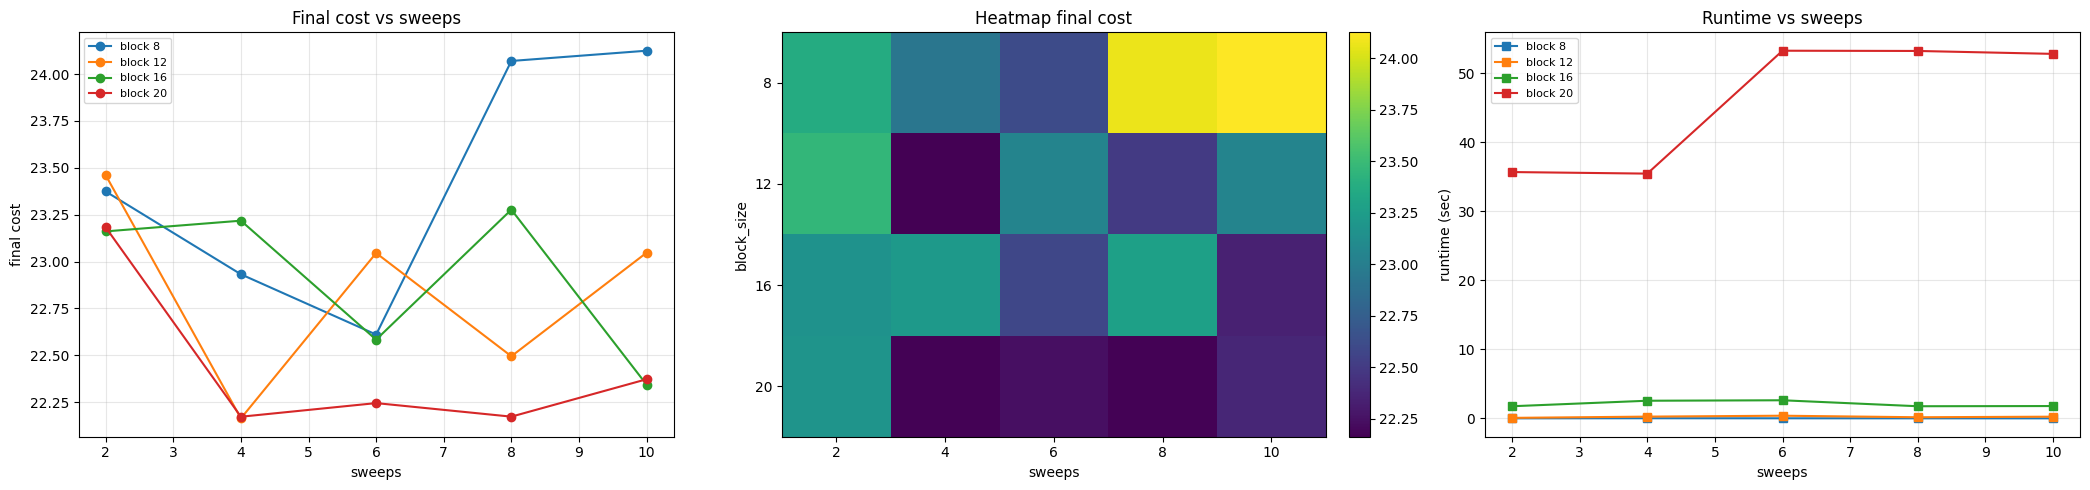

,block_size,sweeps,final_cost,runtime_sec,selected_count
0,8,2,23.373843,0.019973,9
1,8,4,22.932185,0.034097,9
2,8,6,22.610656,0.026391,9
3,8,8,24.069799,0.021344,9
4,8,10,24.124454,0.019542,9
5,12,2,23.460610,0.087815,9
6,12,4,22.163978,0.268662,9
7,12,6,23.045498,0.399761,9
8,12,8,22.495030,0.177587,9
9,12,10,23.047242,0.260283,9



Done.
Selected 9 channels (target K=9).
Final cost: 23.122879
Saved: result_large.json
Saved benchmark: benchmark_sweeps_block_size.json


In [14]:
# ==========================================================
# Run
# ==========================================================
if __name__ == "__main__":
    input_candidates = [
        Path("/kaggle/working/cyber_input_large.json"),
        Path("/home/runner/work/tecQuant/tecQuant/progetto/codice/cyber_input_large.json"),
        Path("cyber_input_large.json")
    ]
    INPUT_JSON = next((str(p) for p in input_candidates if p.exists()), None)
    if INPUT_JSON is None:
        raise FileNotFoundError("cyber_input_large.json non trovato nei path previsti")

    OUTPUT_JSON = "result_large.json"
    BENCHMARK_JSON = "benchmark_sweeps_block_size.json"

    p = load_problem(INPUT_JSON)
    Q, c = build_qubo(p)

    # Esecuzione base
    x_best, cost_best = hybrid_solve(
        Q, c, K=p["K"],
        block_size=16,
        sweeps=8,
        seed=42
    )

    selected = np.where(x_best == 1)[0].tolist()
    result = {
        "input_file": INPUT_JSON,
        "n_channels": int(p["n"]),
        "K_target": int(p["K"]),
        "selected_count": int(len(selected)),
        "final_cost": float(round(cost_best, 6)),
        "selected_channels": selected
    }

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)

    # Test parametrici: sweeps e block size
    SWEEPS_TO_TEST = [2, 4, 6, 8, 10]
    BLOCK_SIZES_TO_TEST = [8, 12, 16, 20]

    benchmark_results = benchmark_solver(
        Q, c, K=p["K"],
        sweeps_values=SWEEPS_TO_TEST,
        block_sizes=BLOCK_SIZES_TO_TEST,
        base_seed=100
    )

    with open(BENCHMARK_JSON, "w", encoding="utf-8") as f:
        json.dump(benchmark_results, f, ensure_ascii=False, indent=2)

    benchmark_df = plot_benchmark_results(benchmark_results)
    display(benchmark_df)

    print("\nDone.")
    print(f"Selected {len(selected)} channels (target K={p['K']}).")
    print(f"Final cost: {cost_best:.6f}")
    print(f"Saved: {OUTPUT_JSON}")
    print(f"Saved benchmark: {BENCHMARK_JSON}")



## *result*

Risultato base: {'input_file': '/kaggle/working/cyber_input_large.json', 'n_channels': 60, 'K_target': 9, 'selected_count': 9, 'final_cost': 23.122879, 'selected_channels': [5, 20, 26, 29, 35, 36, 45, 46, 57]}


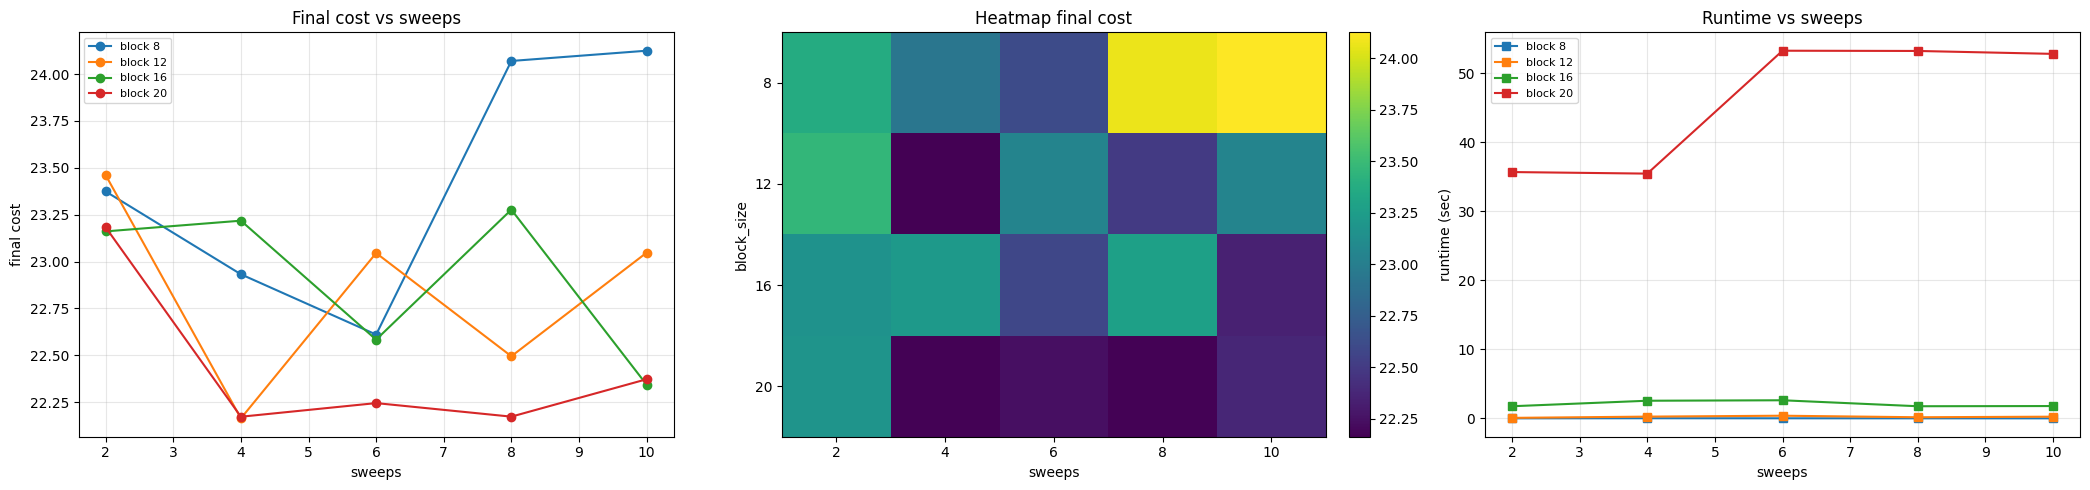

,block_size,sweeps,final_cost,runtime_sec,selected_count
0,8,2,23.373843,0.019973,9
1,8,4,22.932185,0.034097,9
2,8,6,22.610656,0.026391,9
3,8,8,24.069799,0.021344,9
4,8,10,24.124454,0.019542,9
5,12,2,23.460610,0.087815,9
6,12,4,22.163978,0.268662,9
7,12,6,23.045498,0.399761,9
8,12,8,22.495030,0.177587,9
9,12,10,23.047242,0.260283,9


In [15]:
# Lettura risultati salvati
from pathlib import Path

result_candidates = [Path('/kaggle/working/result_large.json'), Path('result_large.json')]
benchmark_candidates = [Path('/kaggle/working/benchmark_sweeps_block_size.json'), Path('benchmark_sweeps_block_size.json')]

result_path = next((p for p in result_candidates if p.exists()), None)
benchmark_path = next((p for p in benchmark_candidates if p.exists()), None)

if result_path:
    with open(result_path, 'r', encoding='utf-8') as f:
        print('Risultato base:', json.load(f))
else:
    print('result_large.json non trovato')

if benchmark_path:
    with open(benchmark_path, 'r', encoding='utf-8') as f:
        benchmark_results = json.load(f)
    df_bench = plot_benchmark_results(benchmark_results)
    display(df_bench)
else:
    print('benchmark_sweeps_block_size.json non trovato')

